In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/Final_Year_Project/Result/Datasets")

In [12]:
from IPython import get_ipython
from IPython.display import display
# %%
from google.colab import drive
drive.mount('/content/drive')
# %%
import os
os.chdir("/content/drive/MyDrive/Final_Year_Project/Result/Datasets")
# %%
# Load datasets
pd_data = pd.read_csv('Copy of combined_dataset_PD2.csv')  # Parkinson's Disease data
hc_data = pd.read_csv('Copy of combined_dataset_HC2.csv')  # Healthy Controls data

# Label datasets
pd_data['Label'] = 1  # Parkinson's Disease labeled as 1
hc_data['Label'] = 0  # Healthy Controls labeled as 0

# Combine datasets
combined_data = pd.concat([pd_data, hc_data], ignore_index=True)

# Drop columns that are completely empty
cleaned_data = combined_data.dropna(axis=1, how='all')

# Save the cleaned data to a new CSV file so it can be loaded later
cleaned_data.to_csv('cleaned_combined_dataset_New2.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<ipython-input-12-5540dc34973e>:12: DtypeWarning: Columns (225,1385) have mixed types. Specify dtype option on import or set low_memory=False.
  hc_data = pd.read_csv('Copy of combined_dataset_HC2.csv')  # Healthy Controls data


<ipython-input-13-610f4fa1fae2>:14: DtypeWarning: Columns (225,1385) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('cleaned_combined_dataset_New2.csv')


Evaluation Metrics (in percentages):
Accuracy: 34.39%
Precision: 24.62%
Recall: 27.08%
F1 Score: 25.79%
Specificity: 39.70%
Geometric Mean: 32.79%


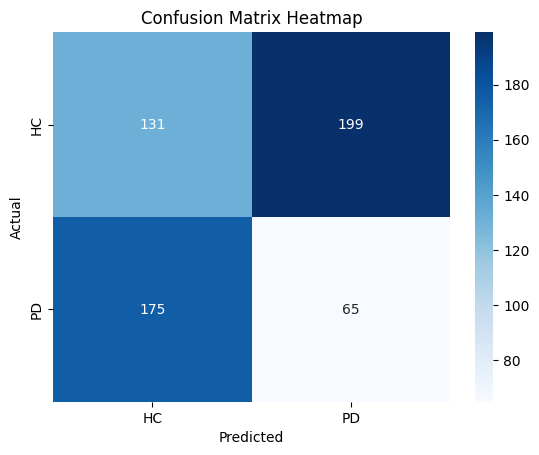

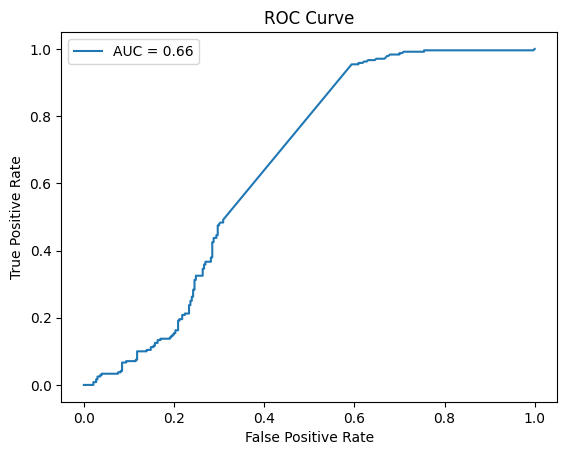

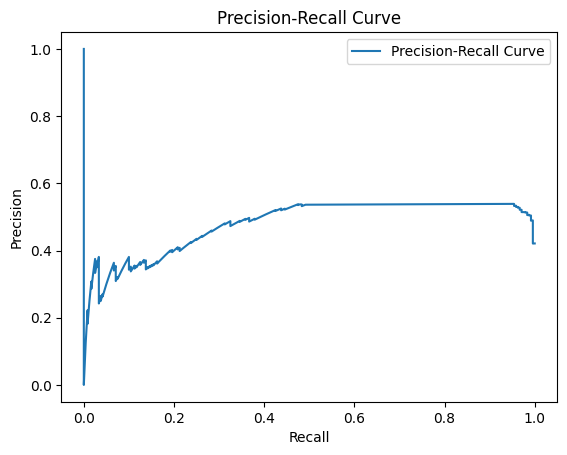

Optimal Threshold: 0.49
Evaluation with Optimal Threshold (in percentages):
Accuracy: 60.00%
Precision: 51.30%
Recall: 98.33%
F1 Score: 67.43%


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Load the cleaned dataset
data = pd.read_csv('cleaned_combined_dataset_New2.csv')

# Separate features and labels
X = data.drop(columns=['Label', 'Filename'])  # Features - Exclude 'Filename' and 'Label'
y = data['Label']                # Target label

# Convert columns that might contain string representations of numbers
# Identify potential columns with mixed types based on the traceback values
# You might need to inspect your data to identify all such columns
columns_to_convert = [col for col in X.columns if X[col].dtype == 'object' or X[col].apply(lambda x: isinstance(x, str) and x.startswith('[')).any()]

for col in columns_to_convert:
    try:
        # Attempt to convert columns that might contain string representations of numbers like '[139.67483108]'
        X[col] = X[col].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float)
    except ValueError:
        # If conversion to float fails after cleaning, consider dropping the column
        print(f"Warning: Could not convert column '{col}' to numeric. Dropping this column.")
        X = X.drop(columns=[col])


# Handle missing values (if any, as a safeguard)
# Now that non-numeric columns are removed or converted, median should work
X.fillna(X.median(), inplace=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Balance classes using SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Train an SVM classifier
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_pred = svm_model.predict(X_test)
y_probs = svm_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred) * 100
precision = precision_score(y_test, y_pred) * 100
recall = recall_score(y_test, y_pred) * 100
f1 = f1_score(y_test, y_pred) * 100
conf_matrix = confusion_matrix(y_test, y_pred)
specificity = (conf_matrix[0, 0] / (conf_matrix[0, 0] + conf_matrix[0, 1])) * 100
g_mean = np.sqrt((recall / 100) * (specificity / 100)) * 100

# Display evaluation metrics
print("Evaluation Metrics (in percentages):")
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")
print(f"Specificity: {specificity:.2f}%")
print(f"Geometric Mean: {g_mean:.2f}%")

# Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_probs)
plt.plot(recall_vals, precision_vals, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# Optimal Threshold Tuning
optimal_idx = np.argmax(precision_vals + recall_vals)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold:.2f}")

# Apply Optimal Threshold
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

# Re-evaluate using the optimal threshold
accuracy_optimal = accuracy_score(y_test, y_pred_optimal) * 100
precision_optimal = precision_score(y_test, y_pred_optimal) * 100
recall_optimal = recall_score(y_test, y_pred_optimal) * 100
f1_optimal = f1_score(y_test, y_pred_optimal) * 100

print("Evaluation with Optimal Threshold (in percentages):")
print(f"Accuracy: {accuracy_optimal:.2f}%")
print(f"Precision: {precision_optimal:.2f}%")
print(f"Recall: {recall_optimal:.2f}%")
print(f"F1 Score: {f1_optimal:.2f}%")